<a href="https://colab.research.google.com/github/Md-Golam-Raiyhan/INSE-6290-/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
R"""INSE 6290 – Real-Data Pipeline
================================
Uses the actual foodDemand dataset (456k rows, 145 weeks, 77 centers, 51 meals).
Aggregates top-10 meals weekly across all centers, then runs:
  - Random Forest vs Lag-4 baseline forecasting
  - Newsvendor + FEFO inventory simulation
  - Supply-chain KPI evaluation
"""

from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

PROJECT_ROOT = Path.cwd()

# ─────────────────────────────────────────────────────────────
# Cost parameters by meal category
# (unit_cost = 40% of avg selling price — standard food COGS ratio)
# shelf_life in weeks: fresh items = 1 week, others = 2 weeks
# ─────────────────────────────────────────────────────────────
FRESH_CATEGORIES = {"Salad", "Soup", "Fish", "Seafood"}

SHELF_LIFE_WEEKS = 1   # fresh
SHELF_LIFE_SHELF = 2   # ambient / longer-life


# ─────────────────────────────────────────────────────────────
# Data loading & preparation
# ─────────────────────────────────────────────────────────────
def load_real_data(top_n_meals: int = 10) -> pd.DataFrame:
    """
    Load, merge, aggregate, and augment the real foodDemand dataset.

    Steps:
    1. Load train.csv + meal_info.csv
    2. Pick top-N meals by total historical demand
    3. Aggregate per (meal_id, week): sum orders, mean price, max promo flags
    4. Derive cost parameters from actual prices
    5. Add shelf-life by meal category
    """
    train  = pd.read_csv(PROJECT_ROOT / "train.csv")
    meals  = pd.read_csv(PROJECT_ROOT / "meal_info.csv")

    # Merge meal category info
    df = train.merge(meals, on="meal_id", how="left")

    # Pick top-N meals by total demand
    top_meals = (
        df.groupby("meal_id")["num_orders"].sum()
        .nlargest(top_n_meals).index.tolist()
    )
    df = df[df["meal_id"].isin(top_meals)].copy()

    # Aggregate across all fulfillment centers per (meal, week)
    agg = df.groupby(["meal_id", "week"]).agg(
        num_orders           = ("num_orders",            "sum"),
        checkout_price       = ("checkout_price",        "mean"),
        base_price           = ("base_price",            "mean"),
        emailer_for_promotion= ("emailer_for_promotion", "max"),
        homepage_featured    = ("homepage_featured",     "max"),
        category             = ("category",              "first"),
        cuisine              = ("cuisine",               "first"),
    ).reset_index()

    # Derived price features
    agg["price_ratio"]    = (agg["checkout_price"] / agg["base_price"]).round(4)   # <1 means discount
    agg["price_discount"] = (agg["base_price"] - agg["checkout_price"]).round(2)   # absolute discount

    # Cost parameters derived from actual prices
    agg["selling_price"]  = agg["checkout_price"].round(2)
    agg["unit_cost"]      = (agg["checkout_price"] * 0.40).round(2)   # 40% COGS
    agg["holding_cost"]   = (agg["unit_cost"] * 0.05).round(3)        # 5% of cost/week
    agg["shortage_cost"]  = (agg["checkout_price"] * 0.50).round(2)   # 50% of price = lost margin + goodwill
    agg["shelf_life_weeks"] = agg["category"].apply(
        lambda c: SHELF_LIFE_WEEKS if c in FRESH_CATEGORIES else SHELF_LIFE_SHELF
    )

    # Week-of-year proxy (week % 52) for seasonality
    agg["week_of_year"] = ((agg["week"] - 1) % 52) + 1

    return agg.sort_values(["meal_id", "week"]).reset_index(drop=True)


# ─────────────────────────────────────────────────────────────
# Feature engineering
# ─────────────────────────────────────────────────────────────
def prepare_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(["meal_id", "week"]).copy()
    grp = df.groupby("meal_id")

    df["lag_1"]     = grp["num_orders"].shift(1)
    df["lag_4"]     = grp["num_orders"].shift(4)    # ~1 month ago
    df["rolling_4"] = grp["num_orders"].shift(1).rolling(4).mean().reset_index(level=0, drop=True)
    df["rolling_8"] = grp["num_orders"].shift(1).rolling(8).mean().reset_index(level=0, drop=True)

    return df


# ─────────────────────────────────────────────────────────────
# Train & forecast
# ─────────────────────────────────────────────────────────────
FEATURE_COLS = [
    "meal_id", "week_of_year",
    "emailer_for_promotion", "homepage_featured",
    "price_ratio", "price_discount",
    "lag_1", "lag_4", "rolling_4", "rolling_8",
]

def train_and_forecast(df: pd.DataFrame, test_weeks: int = 10):
    df    = prepare_features(df).dropna().copy()
    cutoff = df["week"].max() - test_weeks + 1
    train  = df[df["week"] <  cutoff].copy()
    test   = df[df["week"] >= cutoff].copy()

    rf = RandomForestRegressor(
        n_estimators=300, max_depth=12, min_samples_leaf=2, random_state=42
    )
    rf.fit(train[FEATURE_COLS], train["num_orders"])
    test["rf_forecast"]       = np.maximum(0, rf.predict(test[FEATURE_COLS]))
    test["baseline_forecast"] = np.maximum(0, test["lag_4"])   # baseline = 4-week-ago demand

    metrics = {
        "Baseline_MAE":  float(mean_absolute_error(test["num_orders"], test["baseline_forecast"])),
        "Baseline_RMSE": float(np.sqrt(mean_squared_error(test["num_orders"], test["baseline_forecast"]))),
        "RF_MAE":        float(mean_absolute_error(test["num_orders"], test["rf_forecast"])),
        "RF_RMSE":       float(np.sqrt(mean_squared_error(test["num_orders"], test["rf_forecast"]))),
    }

    # Use in-sample FORECAST ERROR std (not raw demand std) for newsvendor safety stock.
    # This correctly captures uncertainty around the model's own predictions.
    train_pred = rf.predict(train[FEATURE_COLS])
    train["rf_residual"]       = train["num_orders"] - train_pred
    train["baseline_residual"] = train["num_orders"] - train["lag_4"].fillna(train["num_orders"].mean())
    rf_residual_std       = train.groupby("meal_id")["rf_residual"].std().to_dict()
    baseline_residual_std = train.groupby("meal_id")["baseline_residual"].std().to_dict()
    residual_std = {"rf": rf_residual_std, "baseline": baseline_residual_std}

    item_params = (
        train.groupby([
            "meal_id", "category", "cuisine",
            "unit_cost", "selling_price",
            "holding_cost", "shortage_cost", "shelf_life_weeks"
        ]).size().reset_index().drop(columns=0)
    )
    # Use average cost params per meal (prices vary week to week)
    item_params = (
        train.groupby("meal_id").agg(
            category      = ("category",       "first"),
            cuisine       = ("cuisine",        "first"),
            unit_cost     = ("unit_cost",      "mean"),
            selling_price = ("selling_price",  "mean"),
            holding_cost  = ("holding_cost",   "mean"),
            shortage_cost = ("shortage_cost",  "mean"),
            shelf_life_weeks = ("shelf_life_weeks", "first"),
        ).reset_index()
    )

    feat_imp = pd.DataFrame({
        "Feature":    FEATURE_COLS,
        "Importance": rf.feature_importances_,
    }).sort_values("Importance", ascending=False).round(4)

    return train, test, metrics, residual_std, item_params, feat_imp


# ─────────────────────────────────────────────────────────────
# Newsvendor Z-score lookup (no SciPy needed)
# ─────────────────────────────────────────────────────────────
def normal_z_from_service(service_level: float) -> float:
    lookup = {
        0.50: 0.0,   0.60: 0.253, 0.65: 0.385, 0.70: 0.524, 0.75: 0.674,
        0.80: 0.842, 0.85: 1.036, 0.90: 1.282, 0.91: 1.341, 0.92: 1.405,
        0.93: 1.476, 0.94: 1.555, 0.95: 1.645, 0.96: 1.751, 0.97: 1.881,
        0.98: 2.054, 0.99: 2.326,
    }
    keys = np.array(sorted(lookup.keys()))
    idx  = np.abs(keys - service_level).argmin()
    return lookup[float(keys[idx])]


# ─────────────────────────────────────────────────────────────
# Inventory simulation — FEFO age-bucket model (weekly periods)
# ─────────────────────────────────────────────────────────────
def simulate_inventory(
    test: pd.DataFrame,
    item_params: pd.DataFrame,
    residual_std: dict,
    forecast_col: str,
) -> pd.DataFrame:
    # residual_std is a dict with keys "rf" and "baseline"
    policy_key = "rf" if "rf" in forecast_col else "baseline"
    std_lookup = residual_std[policy_key]

    params  = item_params.set_index("meal_id").to_dict(orient="index")
    records = []
    state   = {}

    for meal_id, p in params.items():
        life = int(round(p["shelf_life_weeks"]))
        state[meal_id] = {"buckets": [0] * life}

    for week in sorted(test["week"].unique()):
        week_data = test[test["week"] == week].copy()
        for _, row in week_data.iterrows():
            meal_id  = int(row["meal_id"])
            p        = params[meal_id]
            holding  = float(p["holding_cost"])
            shortage = float(p["shortage_cost"])

            crit_ratio = shortage / (shortage + holding)
            z          = normal_z_from_service(round(min(max(crit_ratio, 0.5), 0.99), 2))
            sigma      = std_lookup.get(meal_id, 100.0)
            mu         = max(0.0, float(row[forecast_col]))
            order_qty  = int(round(max(0, mu + z * sigma)))

            buckets   = state[meal_id]["buckets"]
            waste     = buckets[0]                      # oldest bucket expires
            buckets   = buckets[1:] + [order_qty]       # shift age; receive new order
            available = sum(buckets)
            demand    = int(row["num_orders"])
            sold      = min(available, demand)
            remaining = sold
            for i in range(len(buckets)):               # FEFO: consume oldest first
                take       = min(buckets[i], remaining)
                buckets[i] -= take
                remaining  -= take
            end_inv  = sum(buckets)
            stockout = max(0, demand - sold)

            state[meal_id]["buckets"] = buckets
            records.append({
                "week":             week,
                "meal_id":          meal_id,
                "category":         row["category"],
                "cuisine":          row["cuisine"],
                "forecast_method":  forecast_col,
                "forecast":         round(mu, 1),
                "actual_demand":    demand,
                "order_qty":        order_qty,
                "sales":            sold,
                "stockout_units":   stockout,
                "waste_units":      int(waste),
                "ending_inventory": int(end_inv),
                "unit_cost":        round(float(p["unit_cost"]), 2),
                "selling_price":    round(float(p["selling_price"]), 2),
                "emailer_for_promotion": int(row["emailer_for_promotion"]),
                "homepage_featured":     int(row["homepage_featured"]),
            })

    return pd.DataFrame(records)


# ─────────────────────────────────────────────────────────────
# Supply-chain KPIs
# ─────────────────────────────────────────────────────────────
def compute_supply_chain_metrics(sim_df: pd.DataFrame) -> pd.Series:
    total_demand  = sim_df["actual_demand"].sum()
    total_sales   = sim_df["sales"].sum()
    total_orders  = sim_df["order_qty"].sum()
    total_waste   = sim_df["waste_units"].sum()
    avg_inventory = max(1e-6, sim_df["ending_inventory"].mean())
    revenue       = (sim_df["sales"] * sim_df["selling_price"]).sum()
    cogs          = (sim_df["order_qty"] * sim_df["unit_cost"]).sum()
    waste_cost    = (sim_df["waste_units"] * sim_df["unit_cost"]).sum()
    return pd.Series({
        "Total Demand":        int(total_demand),
        "Total Sales":         int(total_sales),
        "Total Ordered":       int(total_orders),
        "Fill Rate":           round(total_sales / total_demand if total_demand else 0, 4),
        "Stockout Rate":       round(sim_df["stockout_units"].sum() / total_demand if total_demand else 0, 4),
        "Food Waste %":        round(total_waste / total_orders if total_orders else 0, 4),
        "Inventory Turnover":  round(total_sales / avg_inventory, 2),
        "Revenue ($)":         round(revenue, 0),
        "COGS ($)":            round(cogs, 0),
        "Waste Cost ($)":      round(waste_cost, 0),
        "Gross Profit ($)":    round(revenue - cogs - waste_cost, 0),
    })


# ─────────────────────────────────────────────────────────────
# CLI runner
# ─────────────────────────────────────────────────────────────
if __name__ == "__main__":
    import json

    print("Loading real dataset…")
    df = load_real_data(top_n_meals=10)
    print(f"Dataset: {df.shape[0]} rows, {df['meal_id'].nunique()} meals, "
          f"weeks {df.week.min()}–{df.week.max()}")

    print("Training models…")
    train, test, fm, residual_std, item_params, feat_imp = train_and_forecast(df)

    print("Simulating inventory…")
    sim_base = simulate_inventory(test, item_params, residual_std, "baseline_forecast")
    sim_rf   = simulate_inventory(test, item_params, residual_std, "rf_forecast")

    scm_base = compute_supply_chain_metrics(sim_base)
    scm_rf   = compute_supply_chain_metrics(sim_rf)

    outdir = PROJECT_ROOT / "outputs"
    outdir.mkdir(exist_ok=True)

    scm = pd.DataFrame({"Baseline": scm_base, "AI-RF": scm_rf})
    pd.DataFrame([fm]).round(4).to_csv(outdir / "forecast_metrics.csv",    index=False)
    scm.to_csv(outdir / "supply_chain_metrics.csv")
    feat_imp.to_csv(outdir / "feature_importance.csv", index=False)
    sim_base.to_csv(outdir / "simulation_baseline.csv", index=False)
    sim_rf.to_csv(outdir / "simulation_ai_rf.csv",     index=False)

    with open(outdir / "summary.json", "w") as f:
        json.dump({
            "forecast_metrics": fm,
            "dataset_rows": int(len(df)),
            "train_weeks": int(train["week"].nunique()),
            "test_weeks":  int(test["week"].nunique()),
            "meals": df["meal_id"].nunique(),
        }, f, indent=2, default=float)

    print("\n=== Forecast Accuracy ===")
    print(pd.DataFrame([fm]).round(2).to_string(index=False))
    print("\n=== Supply Chain KPIs ===")
    print(scm.round(2))
    print(f"\nOutputs saved to: {outdir}")

Loading real dataset…
Dataset: 1450 rows, 10 meals, weeks 1–145
Training models…
Simulating inventory…

=== Forecast Accuracy ===
 Baseline_MAE  Baseline_RMSE  RF_MAE  RF_RMSE
     11697.65       30583.85 4385.54  6730.12

=== Supply Chain KPIs ===
                        Baseline         AI-RF
Total Demand        3.750980e+06  3.750980e+06
Total Sales         3.750980e+06  3.744435e+06
Total Ordered       1.050366e+07  4.884418e+06
Fill Rate           1.000000e+00  1.000000e+00
Stockout Rate       0.000000e+00  0.000000e+00
Food Waste %        4.800000e-01  1.100000e-01
Inventory Turnover  2.386000e+01  8.400000e+01
Revenue ($)         8.856384e+08  8.848159e+08
COGS ($)            1.112219e+09  4.785407e+08
Waste Cost ($)      5.802792e+08  6.385111e+07
Gross Profit ($)   -8.068593e+08  3.424241e+08

Outputs saved to: /content/outputs


Top 10 meals table:


,meal_id,num_orders,category,cuisine
0,2290,9770303,Rice Bowl,Indian
1,1885,8346246,Beverages,Thai
2,1754,6818059,Sandwich,Italian
3,1993,6656856,Beverages,Thai
4,1109,6367773,Rice Bowl,Indian
5,2707,5932792,Beverages,Italian
6,1971,5728620,Sandwich,Italian
7,2826,5090103,Sandwich,Italian
8,1727,4735987,Rice Bowl,Indian
9,1062,4712795,Beverages,Italian


Dataset preparation summary:


,Metric,Value
0,Raw records,456548
1,Unique weeks,145
2,Unique fulfillment centers,77
3,Unique meals in raw data,51
4,Selected meals,10
5,Aggregated records,1450
6,Prepared records after feature engineering,1370


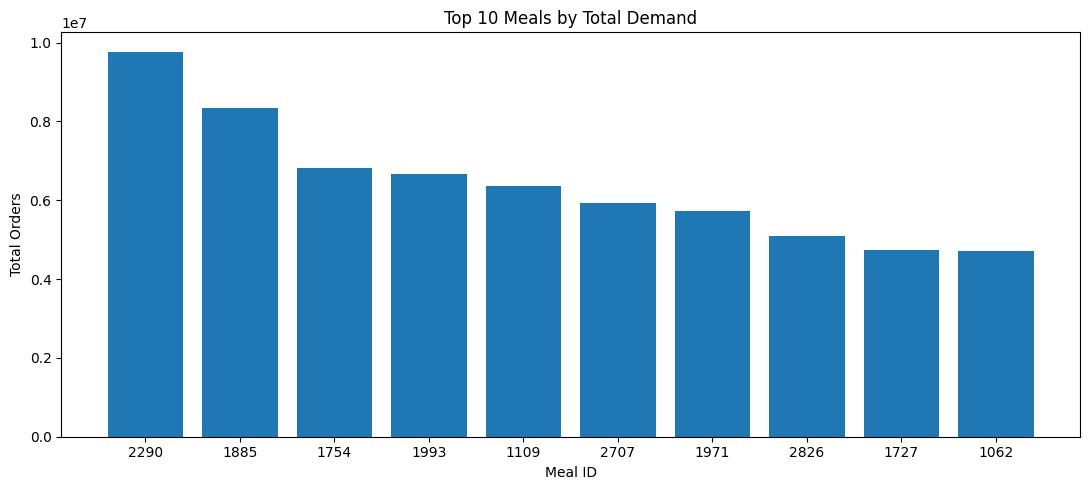

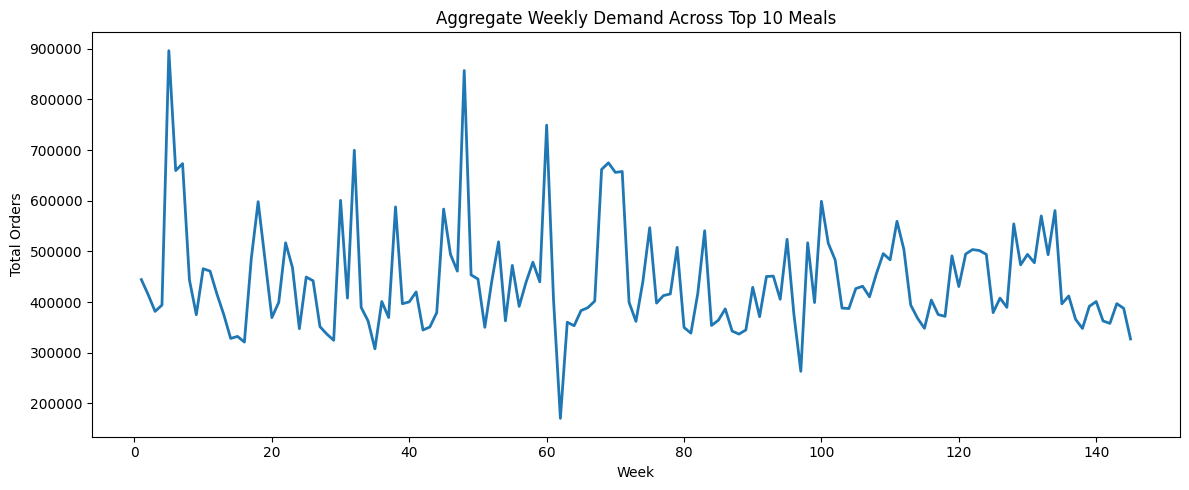

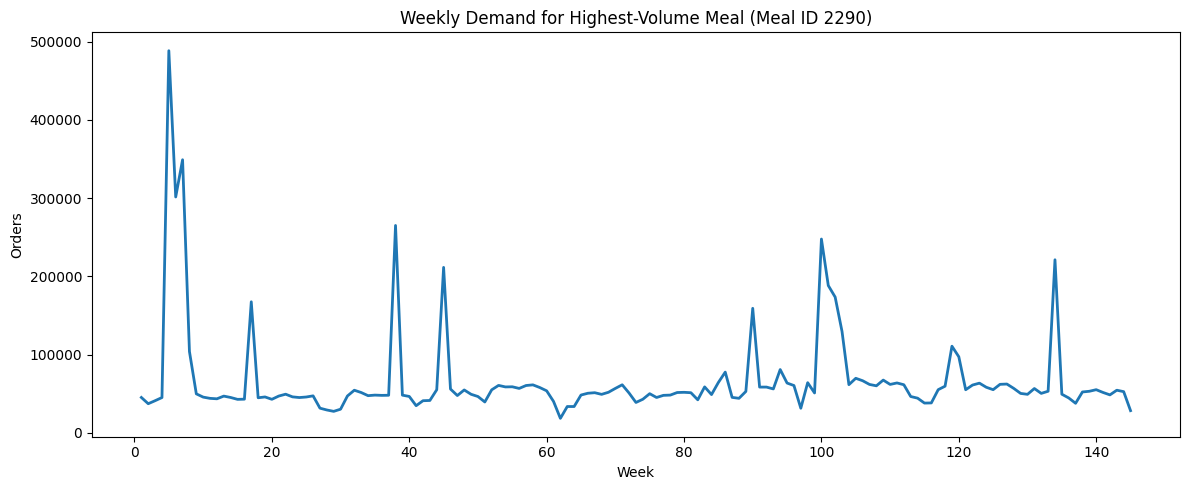

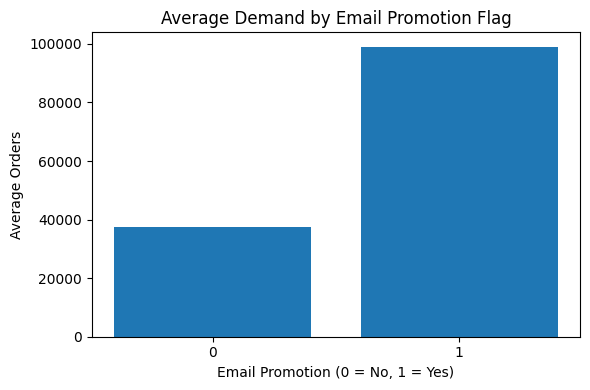

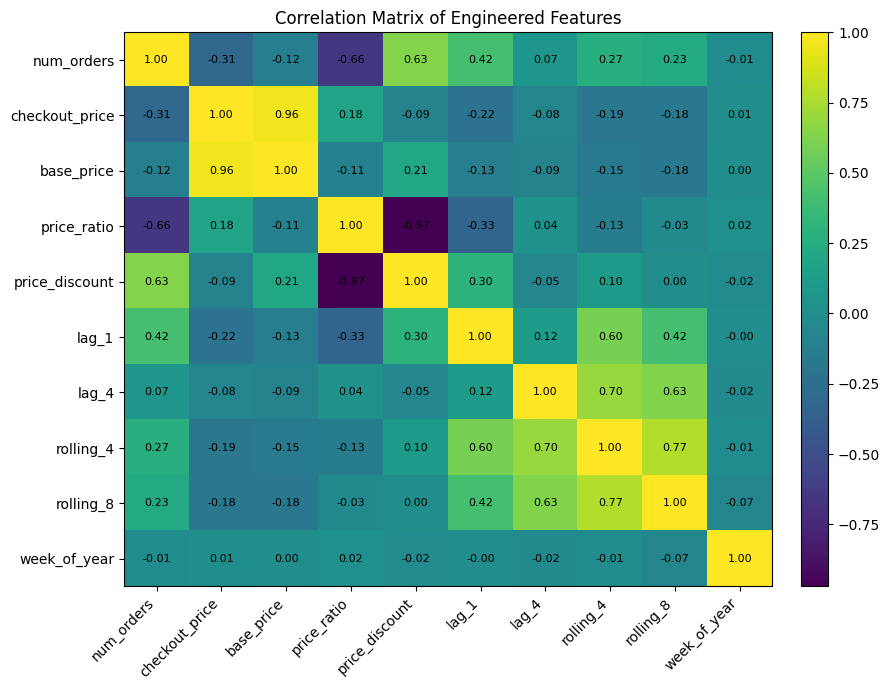


Saved files in outputs/:
- top_10_meals_by_total_demand.csv
- dataset_preparation_summary.csv
- aggregated_top10_meals_weekly.csv
- prepared_dataset_with_features.csv
- top_10_meals_by_total_demand.png
- aggregate_weekly_demand_top10.png
- example_meal_weekly_demand.png
- promotion_effect_on_demand.png
- feature_correlation_matrix.png


In [2]:
# =========================================================
# DATASET DESCRIPTION & PREPARATION - TABLES AND PLOTS
# Add this cell after the main notebook cell has been run
# =========================================================

import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
OUT_DIR = PROJECT_ROOT / "outputs"
OUT_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------
# 1. Load the aggregated real dataset and prepared dataset
# ---------------------------------------------------------
# These functions are already defined in your notebook
agg_df = load_real_data(top_n_meals=10)
prepared_df = prepare_features(agg_df).dropna().copy()

# ---------------------------------------------------------
# 2. Create top-10 meals table
# ---------------------------------------------------------
train_raw = pd.read_csv(PROJECT_ROOT / "train.csv")
meal_info = pd.read_csv(PROJECT_ROOT / "meal_info.csv")

top_10_table = (
    train_raw.groupby("meal_id", as_index=False)["num_orders"]
    .sum()
    .sort_values("num_orders", ascending=False)
    .head(10)
    .merge(meal_info, on="meal_id", how="left")
)

top_10_table.to_csv(OUT_DIR / "top_10_meals_by_total_demand.csv", index=False)

print("Top 10 meals table:")
display(top_10_table)

# ---------------------------------------------------------
# 3. Dataset summary table
# ---------------------------------------------------------
summary_table = pd.DataFrame({
    "Metric": [
        "Raw records",
        "Unique weeks",
        "Unique fulfillment centers",
        "Unique meals in raw data",
        "Selected meals",
        "Aggregated records",
        "Prepared records after feature engineering"
    ],
    "Value": [
        len(train_raw),
        train_raw["week"].nunique(),
        train_raw["center_id"].nunique(),
        train_raw["meal_id"].nunique(),
        10,
        len(agg_df),
        len(prepared_df)
    ]
})

summary_table.to_csv(OUT_DIR / "dataset_preparation_summary.csv", index=False)

print("Dataset preparation summary:")
display(summary_table)

# ---------------------------------------------------------
# 4. Plot 1: Top 10 meals by total demand
# ---------------------------------------------------------
plt.figure(figsize=(11, 5))
plt.bar(top_10_table["meal_id"].astype(str), top_10_table["num_orders"])
plt.title("Top 10 Meals by Total Demand")
plt.xlabel("Meal ID")
plt.ylabel("Total Orders")
plt.tight_layout()
plt.savefig(OUT_DIR / "top_10_meals_by_total_demand.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# 5. Plot 2: Aggregate weekly demand across top 10 meals
# ---------------------------------------------------------
weekly_total = (
    agg_df.groupby("week", as_index=False)["num_orders"]
    .sum()
)

plt.figure(figsize=(12, 5))
plt.plot(weekly_total["week"], weekly_total["num_orders"], linewidth=2)
plt.title("Aggregate Weekly Demand Across Top 10 Meals")
plt.xlabel("Week")
plt.ylabel("Total Orders")
plt.tight_layout()
plt.savefig(OUT_DIR / "aggregate_weekly_demand_top10.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# 6. Plot 3: Example demand series for the highest-demand meal
# ---------------------------------------------------------
example_meal_id = top_10_table.iloc[0]["meal_id"]
example_meal = agg_df[agg_df["meal_id"] == example_meal_id].copy()

plt.figure(figsize=(12, 5))
plt.plot(example_meal["week"], example_meal["num_orders"], linewidth=2)
plt.title(f"Weekly Demand for Highest-Volume Meal (Meal ID {example_meal_id})")
plt.xlabel("Week")
plt.ylabel("Orders")
plt.tight_layout()
plt.savefig(OUT_DIR / "example_meal_weekly_demand.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# 7. Plot 4: Promotion effect on demand
# ---------------------------------------------------------
promo_effect = (
    agg_df.groupby("emailer_for_promotion", as_index=False)["num_orders"]
    .mean()
)

plt.figure(figsize=(6, 4))
plt.bar(promo_effect["emailer_for_promotion"].astype(str), promo_effect["num_orders"])
plt.title("Average Demand by Email Promotion Flag")
plt.xlabel("Email Promotion (0 = No, 1 = Yes)")
plt.ylabel("Average Orders")
plt.tight_layout()
plt.savefig(OUT_DIR / "promotion_effect_on_demand.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# 8. Plot 5: Correlation heatmap of engineered numeric features
# ---------------------------------------------------------
numeric_cols = [
    "num_orders",
    "checkout_price",
    "base_price",
    "price_ratio",
    "price_discount",
    "lag_1",
    "lag_4",
    "rolling_4",
    "rolling_8",
    "week_of_year"
]

corr_df = prepared_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_df.values, aspect="auto")
ax.set_xticks(range(len(corr_df.columns)))
ax.set_xticklabels(corr_df.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_df.index)))
ax.set_yticklabels(corr_df.index)
ax.set_title("Correlation Matrix of Engineered Features")

for i in range(len(corr_df.index)):
    for j in range(len(corr_df.columns)):
        ax.text(j, i, f"{corr_df.values[i, j]:.2f}",
                ha="center", va="center", fontsize=8)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(OUT_DIR / "feature_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# 9. Save the main datasets used in the report
# ---------------------------------------------------------
agg_df.to_csv(OUT_DIR / "aggregated_top10_meals_weekly.csv", index=False)
prepared_df.to_csv(OUT_DIR / "prepared_dataset_with_features.csv", index=False)

print("\nSaved files in outputs/:")
for f in [
    "top_10_meals_by_total_demand.csv",
    "dataset_preparation_summary.csv",
    "aggregated_top10_meals_weekly.csv",
    "prepared_dataset_with_features.csv",
    "top_10_meals_by_total_demand.png",
    "aggregate_weekly_demand_top10.png",
    "example_meal_weekly_demand.png",
    "promotion_effect_on_demand.png",
    "feature_correlation_matrix.png",
]:
    print("-", f)

Forecast performance metrics:


,Baseline_MAE,Baseline_RMSE,RF_MAE,RF_RMSE
0,11697.65,30583.847878,4385.542931,6730.124106


Detailed forecast comparison table (first rows):


,meal_id,week,num_orders,baseline_forecast,rf_forecast,baseline_error,rf_error
135,1062,136,33761,41962.0,33859.174443,8201.0,98.174443
136,1062,137,30233,34603.0,33882.501615,4370.0,3649.501615
137,1062,138,26498,34036.0,30142.068112,7538.0,3644.068112
138,1062,139,31280,34293.0,26678.877530,3013.0,4601.122470
139,1062,140,33077,33761.0,31088.985280,684.0,1988.014720


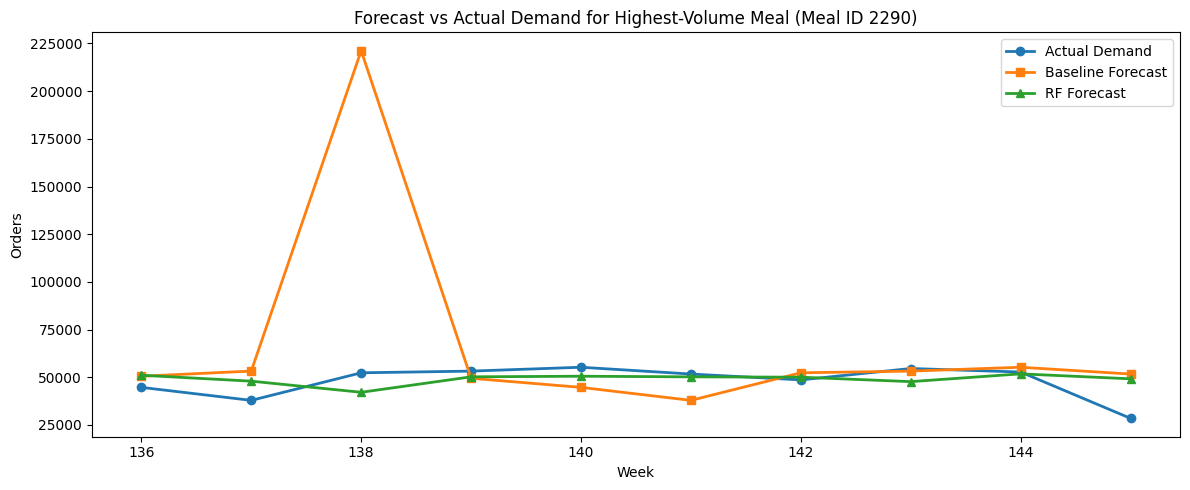

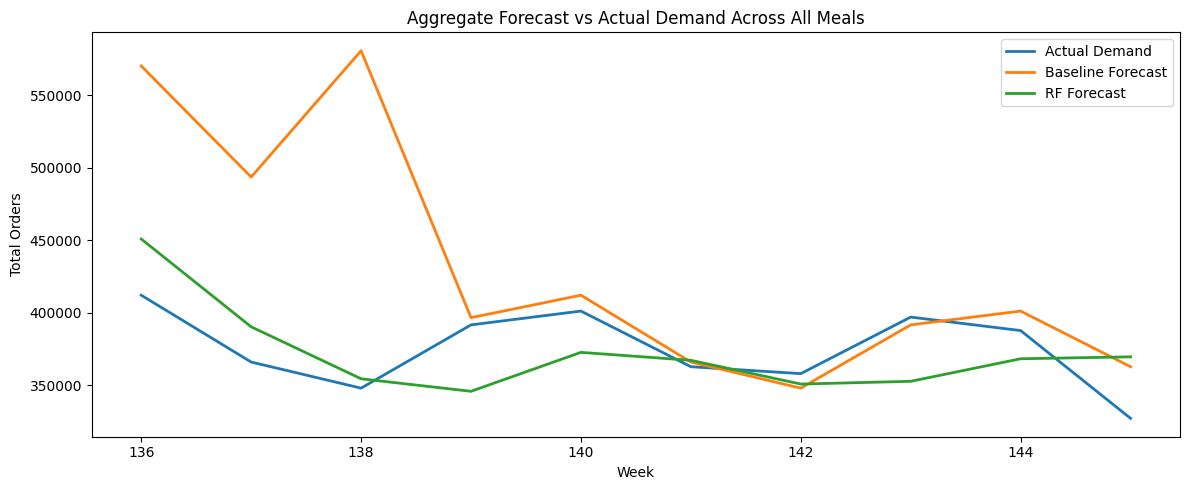

Feature importance table:


,Feature,Importance
0,emailer_for_promotion,0.4163
1,price_ratio,0.1752
2,lag_1,0.1448
3,price_discount,0.0864
4,meal_id,0.0473
5,week_of_year,0.0398
6,lag_4,0.0340
7,rolling_8,0.0333
8,rolling_4,0.0224
9,homepage_featured,0.0005


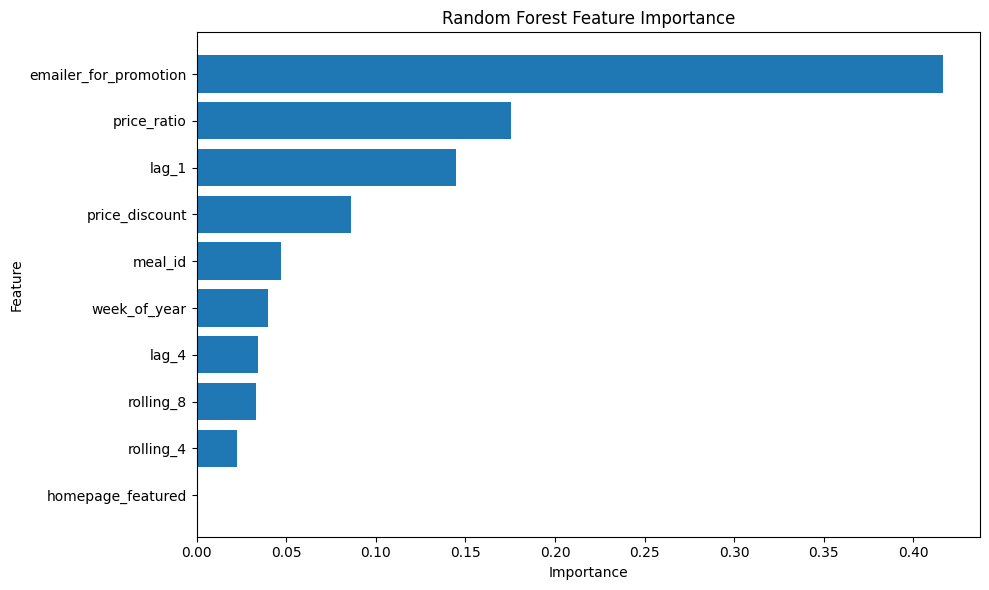

Sample forecast table for highest-volume meal:


,week,actual_demand,baseline_forecast,rf_forecast
1150,136,44702,50542.0,51060.964700
1151,137,37892,53260.0,47959.958256
1152,138,52348,221209.0,42128.744466
1153,139,53231,49477.0,50232.070275
1154,140,55255,44702.0,50547.893831
1155,141,51699,37892.0,50219.618994
1156,142,48628,52348.0,50042.008302
1157,143,54596,53231.0,47713.937821
1158,144,52756,55255.0,51790.128859
1159,145,28468,51699.0,49189.160853


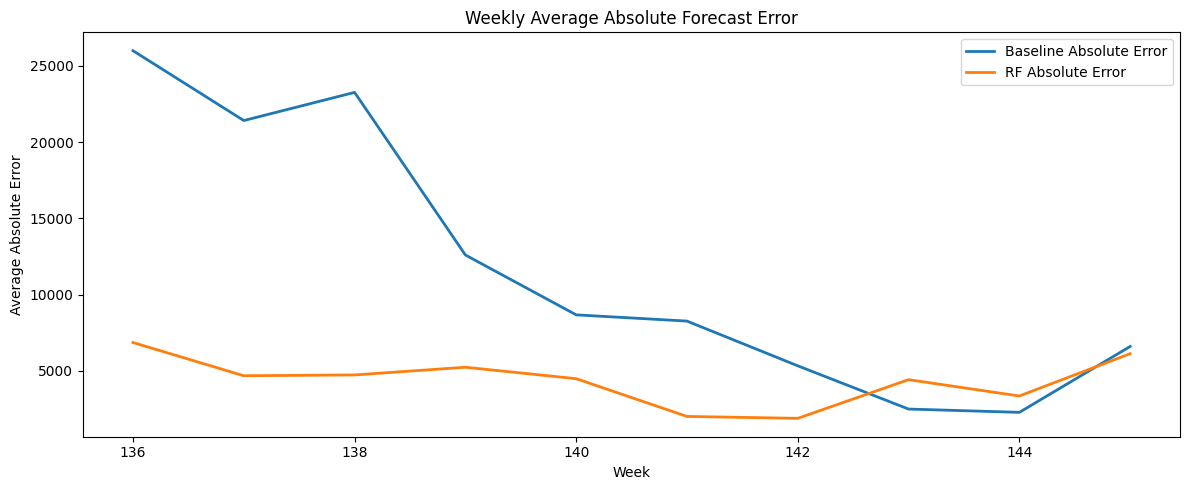


Saved forecasting methodology outputs in outputs/:
- forecast_metrics_table.csv
- forecast_comparison_detailed.csv
- forecast_vs_actual_top_meal.png
- aggregate_forecast_vs_actual.png
- feature_importance_table.csv
- feature_importance_plot.png
- sample_forecast_table_top_meal.csv
- weekly_average_forecast_error.png


In [3]:
# =========================================================
# FORECASTING METHODOLOGY - TABLES AND PLOTS
# Add this cell after the main notebook cell has been run
# =========================================================

import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
OUT_DIR = PROJECT_ROOT / "outputs"
OUT_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------
# 1. Re-run core forecasting pipeline if needed
# ---------------------------------------------------------
# These are already defined in your notebook:
# - load_real_data()
# - train_and_forecast()

df = load_real_data(top_n_meals=10)
train_df, test_df, forecast_metrics, residual_std, item_params, feat_imp = train_and_forecast(df)

# ---------------------------------------------------------
# 2. Forecast metrics table
# ---------------------------------------------------------
# If forecast_metrics is already a DataFrame, keep it
if isinstance(forecast_metrics, pd.DataFrame):
    metrics_df = forecast_metrics.copy()
else:
    # If returned as dict, convert to DataFrame
    metrics_df = pd.DataFrame([forecast_metrics])

metrics_df.to_csv(OUT_DIR / "forecast_metrics_table.csv", index=False)

print("Forecast performance metrics:")
display(metrics_df)

# ---------------------------------------------------------
# 3. Add comparison columns for test set
# ---------------------------------------------------------
# Make sure expected columns exist
# Common names in your notebook:
# - num_orders
# - baseline_forecast
# - rf_forecast

required_cols = ["meal_id", "week", "num_orders", "baseline_forecast", "rf_forecast"]
missing_cols = [c for c in required_cols if c not in test_df.columns]
if missing_cols:
    raise ValueError(f"Missing expected columns in test_df: {missing_cols}")

# ---------------------------------------------------------
# 4. Save detailed forecast comparison table
# ---------------------------------------------------------
forecast_compare_table = test_df[[
    "meal_id", "week", "num_orders", "baseline_forecast", "rf_forecast"
]].copy()

forecast_compare_table["baseline_error"] = (
    forecast_compare_table["num_orders"] - forecast_compare_table["baseline_forecast"]
).abs()

forecast_compare_table["rf_error"] = (
    forecast_compare_table["num_orders"] - forecast_compare_table["rf_forecast"]
).abs()

forecast_compare_table.to_csv(OUT_DIR / "forecast_comparison_detailed.csv", index=False)

print("Detailed forecast comparison table (first rows):")
display(forecast_compare_table.head())

# ---------------------------------------------------------
# 5. Forecast vs actual plot for the highest-volume meal
# ---------------------------------------------------------
# Use the meal with highest total demand in training data
top_meal_id = (
    train_df.groupby("meal_id")["num_orders"]
    .sum()
    .sort_values(ascending=False)
    .index[0]
)

sample_meal = test_df[test_df["meal_id"] == top_meal_id].copy()

plt.figure(figsize=(12, 5))
plt.plot(sample_meal["week"], sample_meal["num_orders"], marker="o", linewidth=2, label="Actual Demand")
plt.plot(sample_meal["week"], sample_meal["baseline_forecast"], marker="s", linewidth=2, label="Baseline Forecast")
plt.plot(sample_meal["week"], sample_meal["rf_forecast"], marker="^", linewidth=2, label="RF Forecast")
plt.title(f"Forecast vs Actual Demand for Highest-Volume Meal (Meal ID {top_meal_id})")
plt.xlabel("Week")
plt.ylabel("Orders")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "forecast_vs_actual_top_meal.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# 6. Aggregate forecast comparison across all meals
# ---------------------------------------------------------
agg_forecast = (
    test_df.groupby("week", as_index=False)[["num_orders", "baseline_forecast", "rf_forecast"]]
    .sum()
)

plt.figure(figsize=(12, 5))
plt.plot(agg_forecast["week"], agg_forecast["num_orders"], linewidth=2, label="Actual Demand")
plt.plot(agg_forecast["week"], agg_forecast["baseline_forecast"], linewidth=2, label="Baseline Forecast")
plt.plot(agg_forecast["week"], agg_forecast["rf_forecast"], linewidth=2, label="RF Forecast")
plt.title("Aggregate Forecast vs Actual Demand Across All Meals")
plt.xlabel("Week")
plt.ylabel("Total Orders")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "aggregate_forecast_vs_actual.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# 7. Feature importance table
# ---------------------------------------------------------
# If feat_imp is already a DataFrame, use it
if isinstance(feat_imp, pd.DataFrame):
    feat_imp_df = feat_imp.copy()
else:
    feat_imp_df = pd.DataFrame(feat_imp)

# Normalize possible column names
if "Importance" not in feat_imp_df.columns:
    # try lowercase or inferred structure
    cols_lower = {c.lower(): c for c in feat_imp_df.columns}
    if "importance" in cols_lower:
        feat_imp_df.rename(columns={cols_lower["importance"]: "Importance"}, inplace=True)
if "Feature" not in feat_imp_df.columns:
    cols_lower = {c.lower(): c for c in feat_imp_df.columns}
    if "feature" in cols_lower:
        feat_imp_df.rename(columns={cols_lower["feature"]: "Feature"}, inplace=True)

feat_imp_df = feat_imp_df.sort_values("Importance", ascending=False).reset_index(drop=True)
feat_imp_df.to_csv(OUT_DIR / "feature_importance_table.csv", index=False)

print("Feature importance table:")
display(feat_imp_df)

# ---------------------------------------------------------
# 8. Feature importance plot
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df["Feature"], feat_imp_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(OUT_DIR / "feature_importance_plot.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# 9. Sample forecast table for report
# ---------------------------------------------------------
sample_forecast_table = sample_meal[[
    "week", "num_orders", "baseline_forecast", "rf_forecast"
]].copy()

sample_forecast_table.rename(columns={
    "num_orders": "actual_demand"
}, inplace=True)

sample_forecast_table.to_csv(OUT_DIR / "sample_forecast_table_top_meal.csv", index=False)

print("Sample forecast table for highest-volume meal:")
display(sample_forecast_table)

# ---------------------------------------------------------
# 10. Optional residual comparison plot
# ---------------------------------------------------------
residual_compare = test_df.copy()
residual_compare["baseline_abs_error"] = (
    residual_compare["num_orders"] - residual_compare["baseline_forecast"]
).abs()
residual_compare["rf_abs_error"] = (
    residual_compare["num_orders"] - residual_compare["rf_forecast"]
).abs()

weekly_error = residual_compare.groupby("week", as_index=False)[["baseline_abs_error", "rf_abs_error"]].mean()

plt.figure(figsize=(12, 5))
plt.plot(weekly_error["week"], weekly_error["baseline_abs_error"], linewidth=2, label="Baseline Absolute Error")
plt.plot(weekly_error["week"], weekly_error["rf_abs_error"], linewidth=2, label="RF Absolute Error")
plt.title("Weekly Average Absolute Forecast Error")
plt.xlabel("Week")
plt.ylabel("Average Absolute Error")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "weekly_average_forecast_error.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# 11. Final list of saved outputs
# ---------------------------------------------------------
print("\nSaved forecasting methodology outputs in outputs/:")
for f in [
    "forecast_metrics_table.csv",
    "forecast_comparison_detailed.csv",
    "forecast_vs_actual_top_meal.png",
    "aggregate_forecast_vs_actual.png",
    "feature_importance_table.csv",
    "feature_importance_plot.png",
    "sample_forecast_table_top_meal.csv",
    "weekly_average_forecast_error.png",
]:
    print("-", f)

,Meal,Baseline,AI-RF
0,1971 - Sandwich (Italian),70947.663167,4912.786842
1,2290 - Rice Bowl (Indian),54462.864326,8713.403519
2,1727 - Rice Bowl (Indian),31612.954650,12952.059176
3,1993 - Beverages (Thai),11446.208765,8780.030535
4,1109 - Rice Bowl (Indian),9965.957902,5171.222033
5,2707 - Beverages (Italian),6665.032813,4139.165748
6,1062 - Beverages (Italian),5364.691044,3381.484507
7,1754 - Sandwich (Italian),5083.659273,6119.999401
8,1885 - Beverages (Thai),4098.325426,2743.914533
9,2826 - Sandwich (Italian),2895.800684,2783.869400


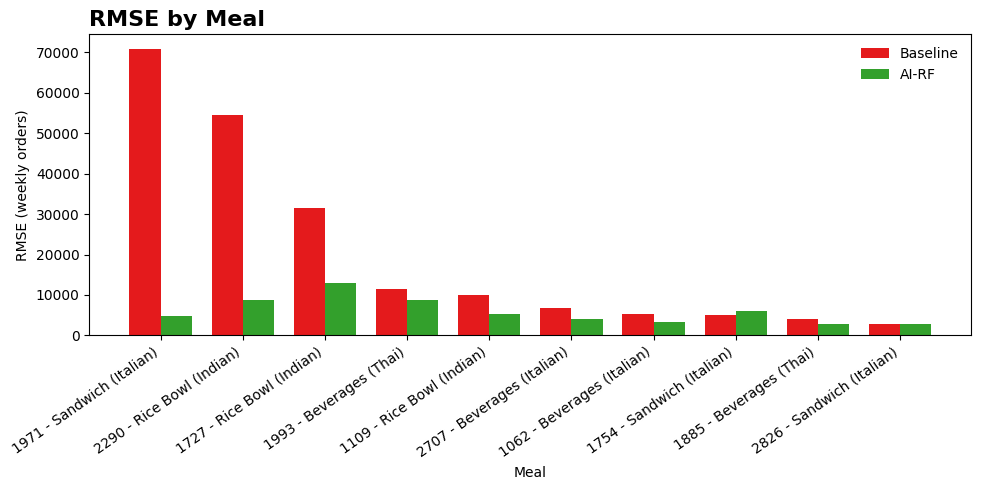

Saved:
- /content/outputs/rmse_by_meal.csv
- /content/outputs/rmse_by_meal.png


In [4]:
# =========================================================
# RMSE BY MEAL PLOT (same style as MAE by Meal)
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Make sure test_df exists and has these columns:
#    meal_id, num_orders, baseline_forecast, rf_forecast
# ---------------------------------------------------------
required_cols = ["meal_id", "num_orders", "baseline_forecast", "rf_forecast"]
missing_cols = [c for c in required_cols if c not in test_df.columns]
if missing_cols:
    raise ValueError(f"Missing expected columns in test_df: {missing_cols}")

# ---------------------------------------------------------
# 2. Create meal labels
#    If your notebook already has a display label, use it.
#    Otherwise build one from meal_id + category/cuisine if available.
# ---------------------------------------------------------
plot_df = test_df.copy()

if "meal_label" not in plot_df.columns:
    if all(col in plot_df.columns for col in ["category", "cuisine"]):
        plot_df["meal_label"] = (
            plot_df["meal_id"].astype(str)
            + " - "
            + plot_df["category"].astype(str)
            + " ("
            + plot_df["cuisine"].astype(str)
            + ")"
        )
    else:
        plot_df["meal_label"] = plot_df["meal_id"].astype(str)

# ---------------------------------------------------------
# 3. Compute RMSE by meal for baseline and AI-RF
# ---------------------------------------------------------
rmse_rows = []

for meal, g in plot_df.groupby("meal_label"):
    baseline_rmse = np.sqrt(np.mean((g["num_orders"] - g["baseline_forecast"]) ** 2))
    rf_rmse = np.sqrt(np.mean((g["num_orders"] - g["rf_forecast"]) ** 2))

    rmse_rows.append({
        "Meal": meal,
        "Baseline": baseline_rmse,
        "AI-RF": rf_rmse
    })

rmse_by_meal = pd.DataFrame(rmse_rows)

# Sort by baseline RMSE descending so it looks similar to your MAE chart
rmse_by_meal = rmse_by_meal.sort_values("Baseline", ascending=False).reset_index(drop=True)

# Save table if needed
rmse_by_meal.to_csv(OUT_DIR / "rmse_by_meal.csv", index=False)

display(rmse_by_meal)

# ---------------------------------------------------------
# 4. Plot
# ---------------------------------------------------------
x = np.arange(len(rmse_by_meal))
width = 0.38

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, rmse_by_meal["Baseline"], width=width, color="#e41a1c", label="Baseline")
plt.bar(x + width/2, rmse_by_meal["AI-RF"], width=width, color="#33a02c", label="AI-RF")

plt.title("RMSE by Meal", loc="left", fontsize=16, fontweight="bold")
plt.ylabel("RMSE (weekly orders)")
plt.xlabel("Meal")
plt.xticks(x, rmse_by_meal["Meal"], rotation=35, ha="right")
plt.legend(frameon=False)
plt.tight_layout()

# Save figure
plt.savefig(OUT_DIR / "rmse_by_meal.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:")
print("-", OUT_DIR / "rmse_by_meal.csv")
print("-", OUT_DIR / "rmse_by_meal.png")

Simulation result samples:


,week,meal_id,category,cuisine,forecast_method,forecast,actual_demand,order_qty,sales,stockout_units,waste_units,ending_inventory,unit_cost,selling_price,emailer_for_promotion,homepage_featured
0,136,1062,Beverages,Italian,baseline_forecast,41962.0,33761,58372,33761,0,0,24611,68.39,170.98,0,0
1,136,1109,Rice Bowl,Indian,baseline_forecast,48417.0,36487,113003,36487,0,0,76516,107.74,269.36,0,0
2,136,1727,Rice Bowl,Indian,baseline_forecast,25348.0,72350,92416,72350,0,0,20066,166.04,415.09,1,1
3,136,1754,Sandwich,Italian,baseline_forecast,44006.0,40915,153980,40915,0,0,113065,111.77,279.42,0,1
4,136,1885,Beverages,Thai,baseline_forecast,53246.0,52972,73008,52972,0,0,20036,50.17,125.43,0,1


,week,meal_id,category,cuisine,forecast_method,forecast,actual_demand,order_qty,sales,stockout_units,waste_units,ending_inventory,unit_cost,selling_price,emailer_for_promotion,homepage_featured
0,136,1062,Beverages,Italian,rf_forecast,33859.2,33761,40214,33761,0,0,6453,68.39,170.98,0,0
1,136,1109,Rice Bowl,Indian,rf_forecast,40201.1,36487,55809,36487,0,0,19322,107.74,269.36,0,0
2,136,1727,Rice Bowl,Indian,rf_forecast,110265.5,72350,119226,72350,0,0,46876,166.04,415.09,1,1
3,136,1754,Sandwich,Italian,rf_forecast,42340.5,40915,59902,40915,0,0,18987,111.77,279.42,0,1
4,136,1885,Beverages,Thai,rf_forecast,55158.9,52972,62786,52972,0,0,9814,50.17,125.43,0,1


KPI comparison table:


,Policy,Total Demand,Total Sales,Total Ordered,Fill Rate,Stockout Rate,Food Waste %,Inventory Turnover,Revenue ($),COGS ($),Waste Cost ($),Gross Profit ($)
0,Baseline,3750980.0,3750980.0,10503655.0,1.0000,0.0000,0.4836,23.86,885638378.0,1.112219e+09,580279176.0,-806859307.0
1,AI-RF,3750980.0,3744435.0,4884418.0,0.9983,0.0017,0.1070,84.00,884815868.0,4.785407e+08,63851113.0,342424086.0


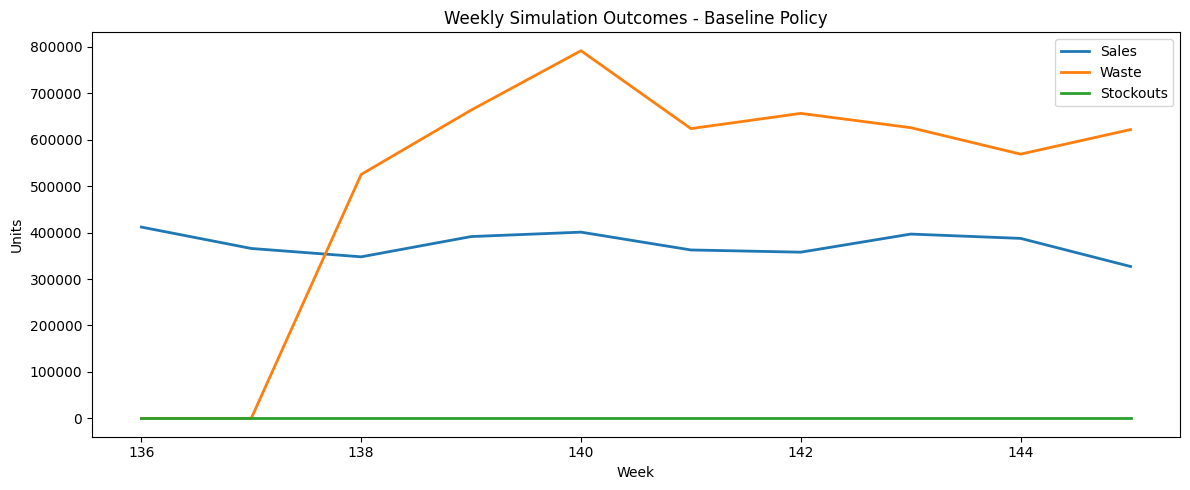

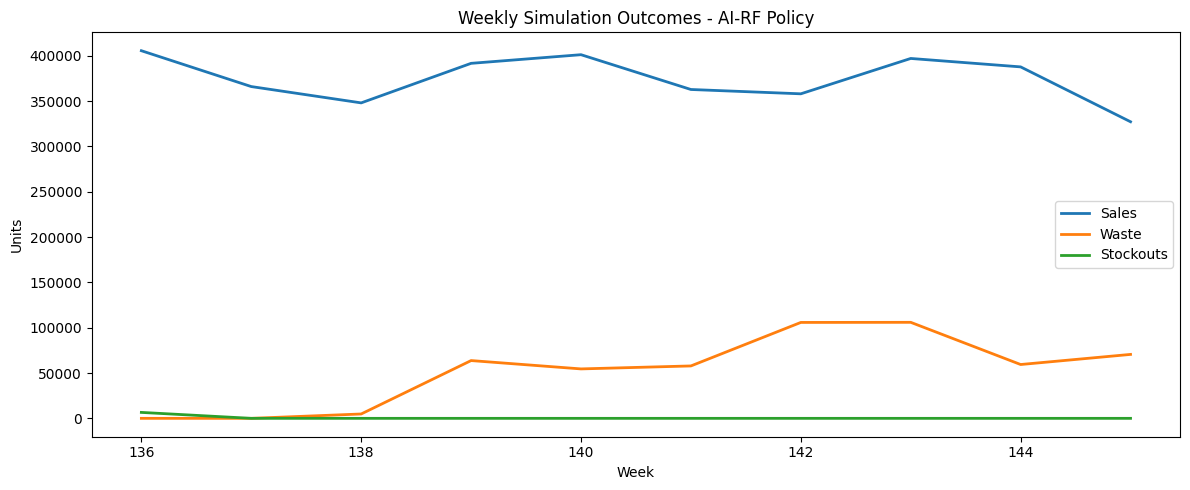

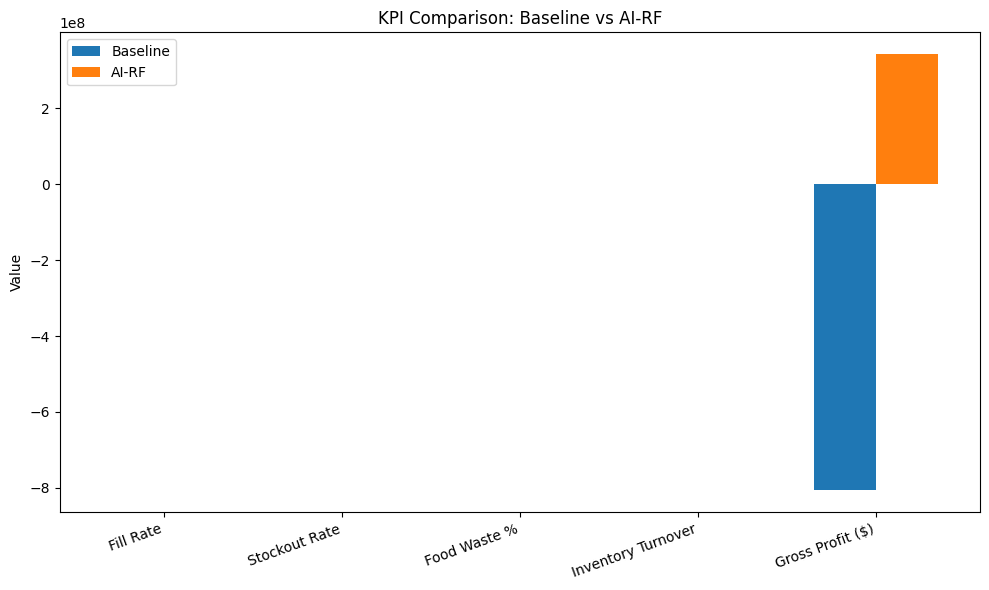

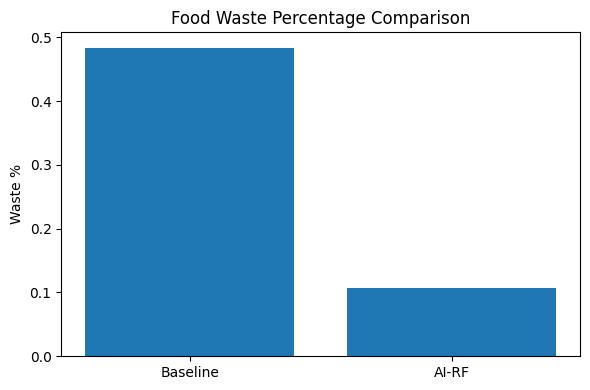

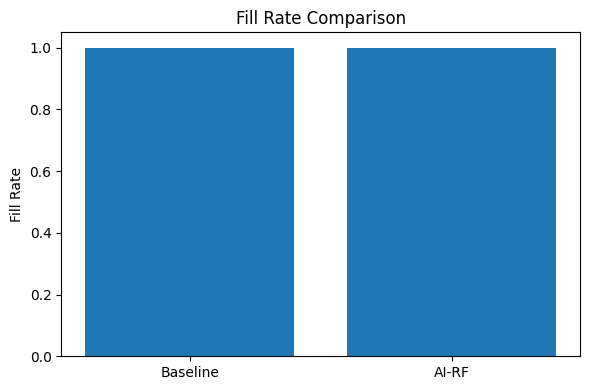

Result summary table:


,Policy,Fill Rate,Stockout Rate,Food Waste %,Inventory Turnover,Gross Profit
0,Baseline,1.0000,0.0000,0.4836,23.86,-806859307.0
1,AI-RF,0.9983,0.0017,0.1070,84.00,342424086.0


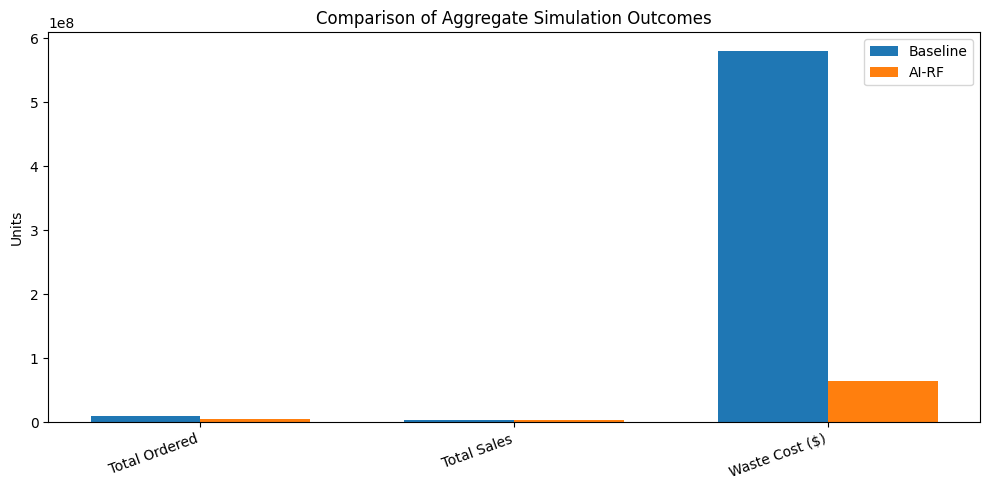


Saved files in outputs/:
- simulation_baseline_results.csv
- simulation_rf_results.csv
- kpi_comparison_table.csv
- weekly_simulation_baseline_summary.csv
- weekly_simulation_rf_summary.csv
- simulation_baseline_plot.png
- simulation_rf_plot.png
- kpi_comparison_bar_chart.png
- food_waste_comparison.png
- fill_rate_comparison.png
- result_summary_table.csv
- aggregate_simulation_outcomes.png


In [5]:
# =========================================================
# SIMULATION + KPI + RESULTS TABLES AND PLOTS
# Add this cell after the main notebook cell has been run
# =========================================================

import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
OUT_DIR = PROJECT_ROOT / "outputs"
OUT_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------
# 1. Re-run the full pipeline if needed
# ---------------------------------------------------------
# These functions are already defined in your notebook:
# - load_real_data()
# - train_and_forecast()
# - simulate_inventory()
# - compute_supply_chain_metrics()

df = load_real_data(top_n_meals=10)
train_df, test_df, forecast_metrics, residual_std, item_params, feat_imp = train_and_forecast(df)

# baseline simulation
sim_baseline = simulate_inventory(
    test=test_df.copy(),
    item_params=item_params,
    residual_std=residual_std,
    forecast_col="baseline_forecast"
)

# AI / RF simulation
sim_rf = simulate_inventory(
    test=test_df.copy(),
    item_params=item_params,
    residual_std=residual_std,
    forecast_col="rf_forecast"
)

# KPI summary
kpi_baseline = compute_supply_chain_metrics(sim_baseline)
kpi_rf = compute_supply_chain_metrics(sim_rf)

# ---------------------------------------------------------
# 2. Save raw simulation outputs
# ---------------------------------------------------------
sim_baseline.to_csv(OUT_DIR / "simulation_baseline_results.csv", index=False)
sim_rf.to_csv(OUT_DIR / "simulation_rf_results.csv", index=False)

print("Simulation result samples:")
display(sim_baseline.head())
display(sim_rf.head())

# ---------------------------------------------------------
# 3. KPI comparison table
# ---------------------------------------------------------
# Convert Series to single-row DataFrames, preserving the Series index as columns
kpi_baseline_df = pd.DataFrame([kpi_baseline])
kpi_rf_df = pd.DataFrame([kpi_rf])

kpi_baseline_df["Policy"] = "Baseline"
kpi_rf_df["Policy"] = "AI-RF"

kpi_compare = pd.concat([kpi_baseline_df, kpi_rf_df], ignore_index=True)

# Reorder columns if present
preferred_cols = [
    "Policy",
    "Total Demand",
    "Total Sales",
    "Total Ordered",
    "Fill Rate",
    "Stockout Rate",
    "Food Waste %",
    "Inventory Turnover",
    "Revenue ($)",
    "COGS ($)",
    "Waste Cost ($)",
    "Gross Profit ($)"
]
existing_cols = [c for c in preferred_cols if c in kpi_compare.columns]
remaining_cols = [c for c in kpi_compare.columns if c not in existing_cols]
kpi_compare = kpi_compare[existing_cols + remaining_cols]

kpi_compare.to_csv(OUT_DIR / "kpi_comparison_table.csv", index=False)

print("KPI comparison table:")
display(kpi_compare)

# ---------------------------------------------------------
# 4. Simulation summary by week
# ---------------------------------------------------------
# Try to infer common column names
def get_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"None of these columns found: {candidates}")

week_col = get_col(sim_baseline, ["week"])
sales_col = get_col(sim_baseline, ["sales", "units_sold", "sold_units"])
waste_col = get_col(sim_baseline, ["waste", "waste_units", "expired_units"])
stockout_col = get_col(sim_baseline, ["stockout", "stockout_units", "unmet_demand"])

weekly_base = sim_baseline.groupby(week_col, as_index=False)[[sales_col, waste_col, stockout_col]].sum()
weekly_rf = sim_rf.groupby(week_col, as_index=False)[[sales_col, waste_col, stockout_col]].sum()

weekly_base.to_csv(OUT_DIR / "weekly_simulation_baseline_summary.csv", index=False)
weekly_rf.to_csv(OUT_DIR / "weekly_simulation_rf_summary.csv", index=False)

# ---------------------------------------------------------
# 5. Plot 1: Baseline simulation results over time
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(weekly_base[week_col], weekly_base[sales_col], label="Sales", linewidth=2)
plt.plot(weekly_base[week_col], weekly_base[waste_col], label="Waste", linewidth=2)
plt.plot(weekly_base[week_col], weekly_base[stockout_col], label="Stockouts", linewidth=2)
plt.title("Weekly Simulation Outcomes - Baseline Policy")
plt.xlabel("Week")
plt.ylabel("Units")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "simulation_baseline_plot.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# 6. Plot 2: AI-RF simulation results over time
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(weekly_rf[week_col], weekly_rf[sales_col], label="Sales", linewidth=2)
plt.plot(weekly_rf[week_col], weekly_rf[waste_col], label="Waste", linewidth=2)
plt.plot(weekly_rf[week_col], weekly_rf[stockout_col], label="Stockouts", linewidth=2)
plt.title("Weekly Simulation Outcomes - AI-RF Policy")
plt.xlabel("Week")
plt.ylabel("Units")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "simulation_rf_plot.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# 7. Plot 3: KPI comparison bar chart
# ---------------------------------------------------------
# choose the most important comparable metrics if they exist
metric_candidates = [
    "Fill Rate",
    "Stockout Rate",
    "Food Waste %",
    "Inventory Turnover",
    "Gross Profit ($)"
]
metrics_to_plot = [m for m in metric_candidates if m in kpi_compare.columns]

if len(metrics_to_plot) > 0:
    plot_kpi = kpi_compare.set_index("Policy")[metrics_to_plot].T

    plt.figure(figsize=(10, 6))
    x = np.arange(len(plot_kpi.index))
    width = 0.35

    plt.bar(x - width/2, plot_kpi["Baseline"], width=width, label="Baseline")
    plt.bar(x + width/2, plot_kpi["AI-RF"], width=width, label="AI-RF")

    plt.xticks(x, plot_kpi.index, rotation=20, ha="right")
    plt.ylabel("Value")
    plt.title("KPI Comparison: Baseline vs AI-RF")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / "kpi_comparison_bar_chart.png", dpi=300, bbox_inches="tight")
    plt.show()

# ---------------------------------------------------------
# 8. Plot 4: Waste comparison only
# ---------------------------------------------------------
if "Food Waste %" in kpi_compare.columns:
    waste_vals = kpi_compare.set_index("Policy")["Food Waste %"]

    plt.figure(figsize=(6, 4))
    plt.bar(waste_vals.index, waste_vals.values)
    plt.title("Food Waste Percentage Comparison")
    plt.ylabel("Waste %")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "food_waste_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()

# ---------------------------------------------------------
# 9. Plot 5: Fill rate comparison only
# ---------------------------------------------------------
if "Fill Rate" in kpi_compare.columns:
    fill_vals = kpi_compare.set_index("Policy")["Fill Rate"]

    plt.figure(figsize=(6, 4))
    plt.bar(fill_vals.index, fill_vals.values)
    plt.title("Fill Rate Comparison")
    plt.ylabel("Fill Rate")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "fill_rate_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()

# ---------------------------------------------------------
# 10. Result summary table for report
# ---------------------------------------------------------
# Create a clean summary table if the expected KPI columns exist
summary_rows = []

for policy_name, row in kpi_compare.set_index("Policy").iterrows():
    summary_rows.append({
        "Policy": policy_name,
        "Fill Rate": row["Fill Rate"] if "Fill Rate" in row else np.nan,
        "Stockout Rate": row["Stockout Rate"] if "Stockout Rate" in row else np.nan,
        "Food Waste %": row["Food Waste %"] if "Food Waste %" in row else np.nan,
        "Inventory Turnover": row["Inventory Turnover"] if "Inventory Turnover" in row else np.nan,
        "Gross Profit": row["Gross Profit ($)"] if "Gross Profit ($)" in row else np.nan,
    })

result_summary_table = pd.DataFrame(summary_rows)
result_summary_table.to_csv(OUT_DIR / "result_summary_table.csv", index=False)

print("Result summary table:")
display(result_summary_table)

# ---------------------------------------------------------
# 11. Optional: comparison of total ordered / sold / wasted if columns exist
# ---------------------------------------------------------
possible_totals = []
for candidate in ["Total Ordered", "total_inventory"]:
    if candidate in kpi_compare.columns:
        possible_totals.append(candidate)
        break

if "Total Sales" in kpi_compare.columns:
    possible_totals.append("Total Sales")

for candidate in ["Waste Cost ($)", "Waste Units"]:
    if candidate in kpi_compare.columns:
        possible_totals.append(candidate)
        break

if len(possible_totals) > 0:
    totals_plot = kpi_compare.set_index("Policy")[possible_totals].T

    plt.figure(figsize=(10, 5))
    x = np.arange(len(totals_plot.index))
    width = 0.35

    plt.bar(x - width/2, totals_plot["Baseline"], width=width, label="Baseline")
    plt.bar(x + width/2, totals_plot["AI-RF"], width=width, label="AI-RF")

    plt.xticks(x, totals_plot.index, rotation=20, ha="right")
    plt.ylabel("Units")
    plt.title("Comparison of Aggregate Simulation Outcomes")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / "aggregate_simulation_outcomes.png", dpi=300, bbox_inches="tight")
    plt.show()

# ---------------------------------------------------------
# 12. Final output list
# ---------------------------------------------------------
print("\nSaved files in outputs/:")
for f in [
    "simulation_baseline_results.csv",
    "simulation_rf_results.csv",
    "kpi_comparison_table.csv",
    "weekly_simulation_baseline_summary.csv",
    "weekly_simulation_rf_summary.csv",
    "simulation_baseline_plot.png",
    "simulation_rf_plot.png",
    "kpi_comparison_bar_chart.png",
    "food_waste_comparison.png",
    "fill_rate_comparison.png",
    "result_summary_table.csv",
    "aggregate_simulation_outcomes.png",
]:
    if (OUT_DIR / f).exists():
        print("-", f)